# 4. Rispondere alle domande
Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe
- Mostrami le vendite maggiori di 10

- Mostrami i dati del 2018

- Mostrami le vendite maggiori di 13 e l'anno è il 2018

- Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

- Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

- Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J



In [1]:
import pandas as pd

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)
sales

,employee,sales,year
0,Katrina,14,2018
1,Guanyu,17,2019
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019
6,Esperanza,7,2019
7,Alaina,15,2020
8,Egweyn,5,2020


In [6]:
#vendite maggiori di 10
#sales[sales['sales'] > 10]
sales.query('sales > 10')

,employee,sales,year
0,Katrina,14,2018
1,Guanyu,17,2019
3,Roman,12,2018
7,Alaina,15,2020


In [5]:
sales.query('year == 2018')

,employee,sales,year
0,Katrina,14,2018
3,Roman,12,2018


In [14]:
sales.query('year == 2018 & sales > 13')

,employee,sales,year
0,Katrina,14,2018


In [15]:
sales.query('not(year == 2018 & sales > 13)')

,employee,sales,year
1,Guanyu,17,2019
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019
6,Esperanza,7,2019
7,Alaina,15,2020
8,Egweyn,5,2020


In [16]:
sales.query('(sales / 3) > 3')

,employee,sales,year
0,Katrina,14,2018
1,Guanyu,17,2019
3,Roman,12,2018
7,Alaina,15,2020


In [19]:
sales.query('employee > "J"')

,employee,sales,year
0,Katrina,14,2018
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019


# 5. Analisi di un dataset di video giochi
1. Quanti videogiochi sono stati pubblicati
2. Quali sono i generi più popolari? Mostralo con un bar plot
3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
4. Prova a riprodurre questo plot 

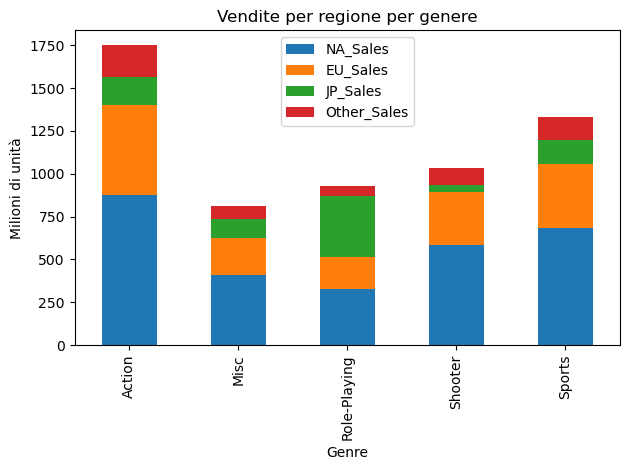


In [1]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [2]:
#Quanti videogiochi sono stati pubblicati
num_games = df['Name'].nunique()
num_games

11493

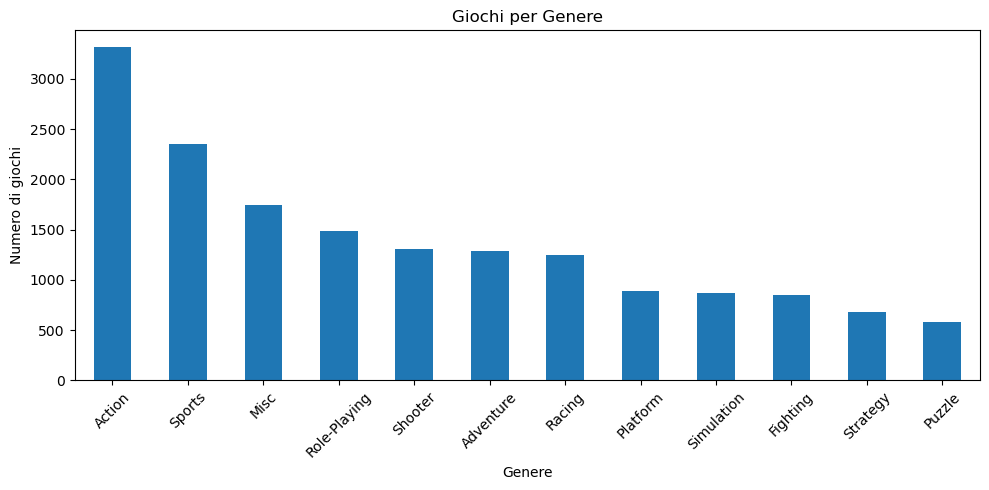

In [20]:
#Quali sono i generi più popolari? Mostralo con un bar plot
genre_counts = df['Genre'].value_counts()

plt.figure(figsize=(10, 5))
genre_counts.plot(kind='bar')
plt.title('Giochi per Genere')
plt.ylabel('Numero di giochi')
plt.xlabel('Genere')
plt.xticks(rotation=45)
plt.tight_layout()

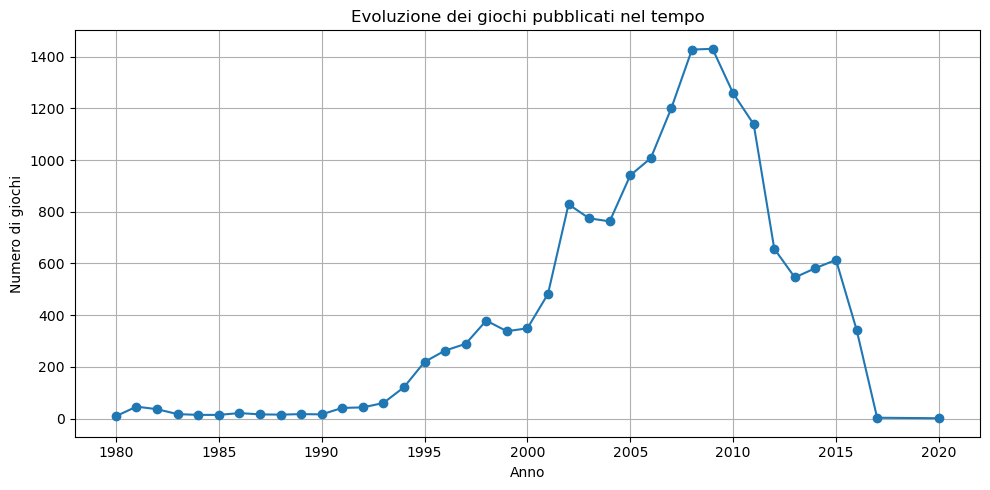

In [21]:
#Plotta l'evoluzione del numero di giochi pubblicati nel tempo
games_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
games_per_year.plot(kind='line', marker='o')
plt.title('Evoluzione dei giochi pubblicati nel tempo')
plt.ylabel('Numero di giochi')
plt.xlabel('Anno')
plt.grid(True)
plt.tight_layout()

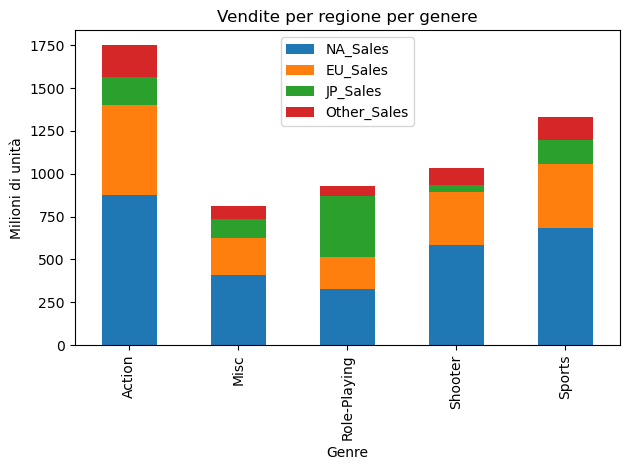

In [ ]:
top_generi = genre_counts.nlargest(5).index
#df_top = df[df['Genre'].isin(top_generi)]
df_top = df[df['Genre'].apply(lambda g: g in top_generi)]
vendite_regioni = df_top.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
vendite_regioni.plot(kind='bar', stacked=True, title='Vendite per regione per genere')
plt.ylabel('Milioni di unità')
plt.tight_layout()
plt.show()